In the Linear classification part we were introduced to a classifier which was **perceptron** which had a neural network structure to it but it had one problem, it had a step-like function behaviour that if the value of the function was above zero it count it as the class 1 and otherwise it counted it as class 2, It kind of was using the sign of the result, but it's not the reality. The fact is that most of the times we have a confidence degree. There are times that we're hundred percent sure of a prediction but in the real world there are uncerntainaty and we're just a percentage .sure about the prediction, We call this percentage the **confidence**. To have a better model to be able to show this **confidence** in our predictions we use **Logistic Regression**.

## Logistic Regression:

+ **Definition**:

    Logistic regression is a supervised machine learning algorithm, used for **binary classification** problems, where the output label $y \in {0, 1}$.
    Instead of predicting the target directly as a linear combination of features, logistic regression predicts the **probability** that a given input belongs to **class 1**(positive class):
    $$P(y = 1 | x) = \sigma{(W^Tx + b)} = \frac{1}{1 + e^{-(w^Tx + b)}}$$

    + x => Input feature
    + w => weight vector
    + b => bias($w_0$)
    + $\sigma(z)$ = **sigmoid function**

    The final prediction(label) is made by thresholding:
    $$
    \hat{y} = 
    \begin{cases}
    1 & \text{if } P(y = 1 \mid \mathbf{x}) \geq 0.5 \\
    0 & \text{otherwise}
    \end{cases}
    $$

> The sigmoid function gives us a number **between**(despite linear classification) 0 and 1 **smoothly**, this **smoothed** characteristic made by sigmoid function makes it **differentiable**.


**Why do we use sigmoid function in logistic regression, instead of a step function like perceptron?**

Because step functions are not **differentiable**, and that breaks **gradient-based optimization**. 
Step function givese only 0 or 1, and you can't say, "This sample is 80% likely to be malignant", and you cannot rank predictions by **confidencee**. Instead logistic regression's **sigmoid** gives us soft outputs(e.g. 0.2, 0.6, 0.95) and are good for modeling **uncertainty** which is useful in real-world applications. If we try to define a loss function usisng a step output, the error surface becomes **non-convex** and **discontinuous**

+ **Sigmoid function**:

$$\sigma{(z)} = \frac{1}{1 + e^{-z}}$$

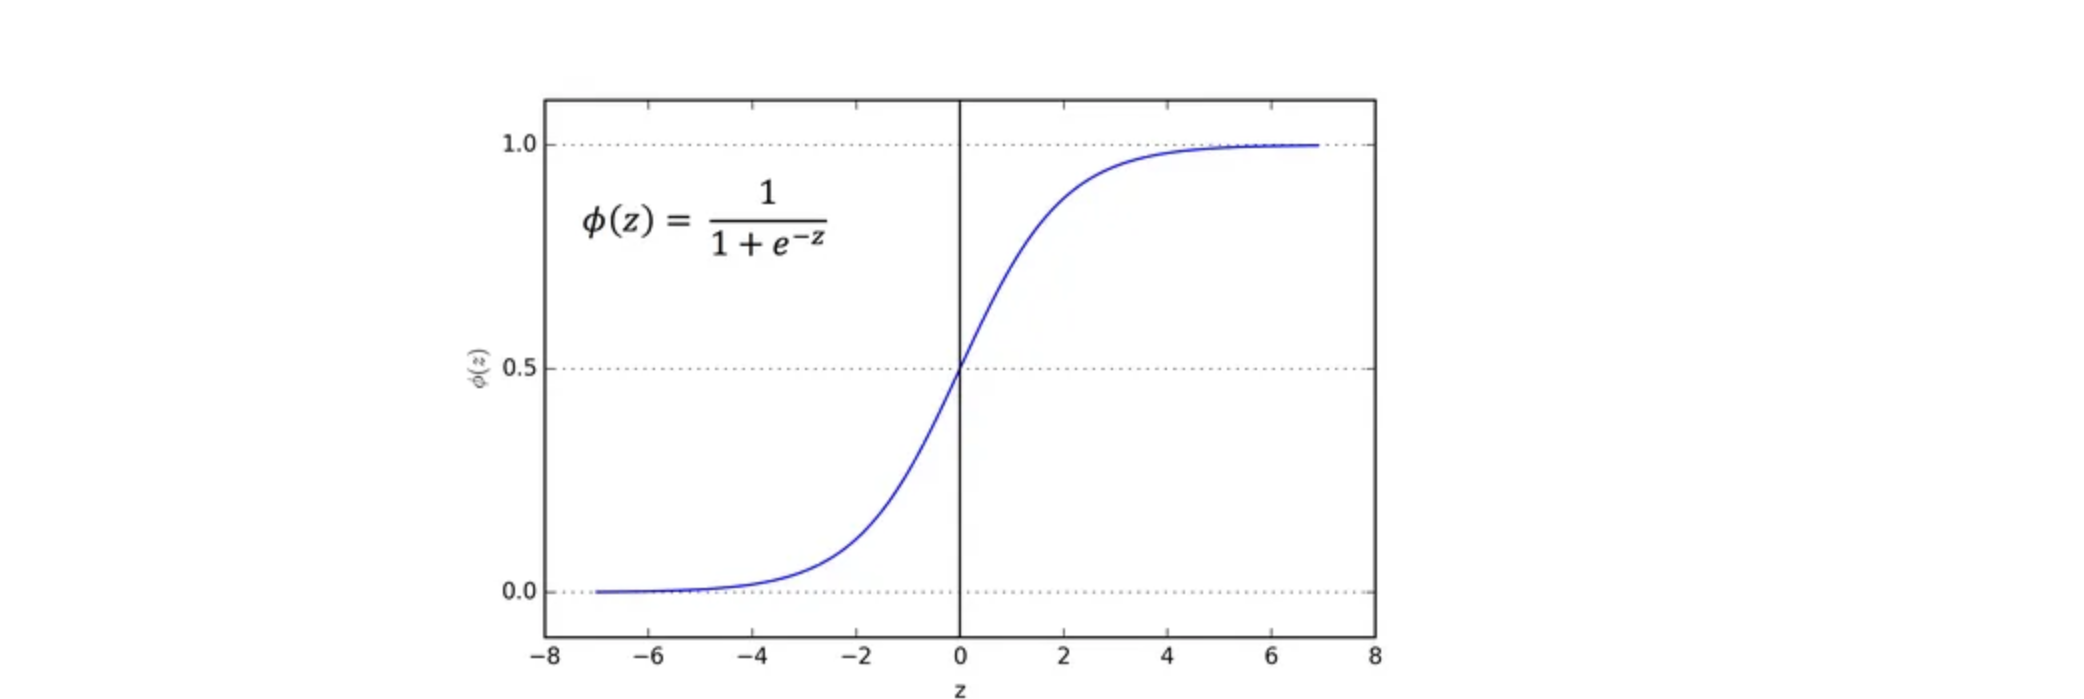


The sigmoid function's differential:

$$\frac{\partial \sigma}{\partial z} = \frac{e^{-z}}{(1 + e^{-z})^2} = \sigma(z) \dot (1- \sigma(z))$$

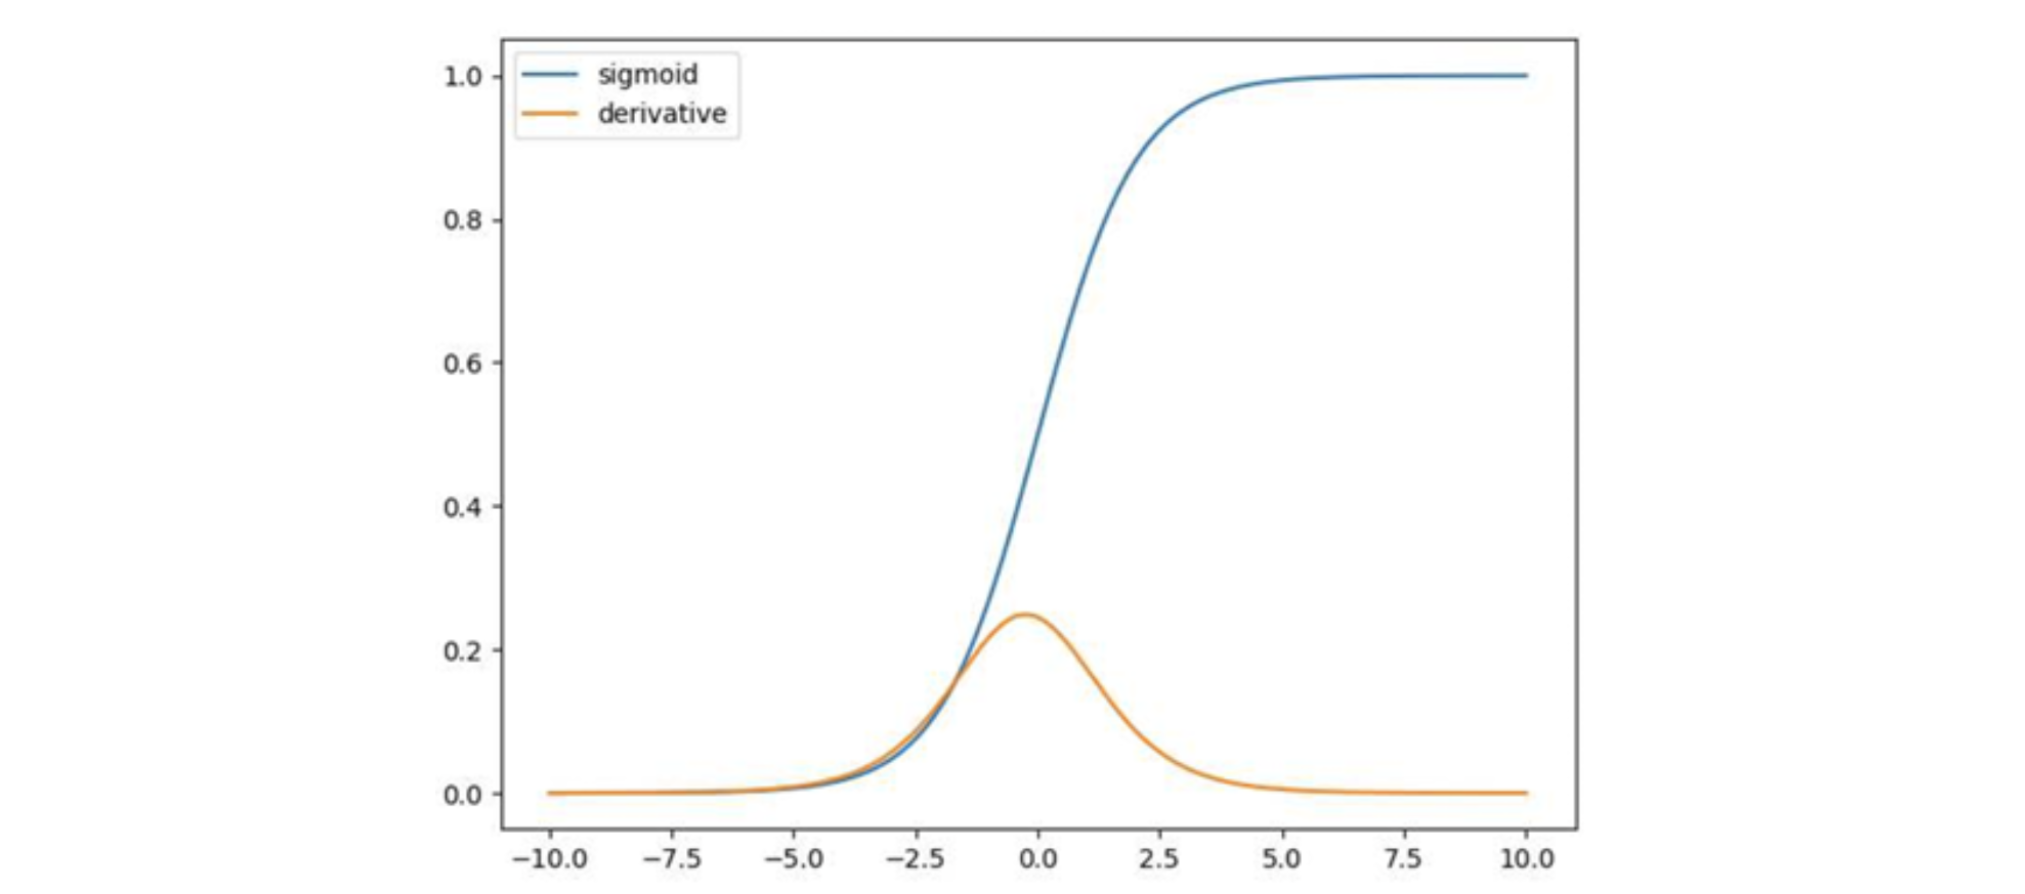

#### Decision Surface

As in the linear classification we also have a d-1 hyperplane which classify between our data samples. 

Decision surface or decision boundry is the region of a problem space in which the output label of a classifier is ambigious (could be linear or non-linear).
In binary classification it is where the probability of a sample belonging to each $y=0$ and $y=1$ is **equal**

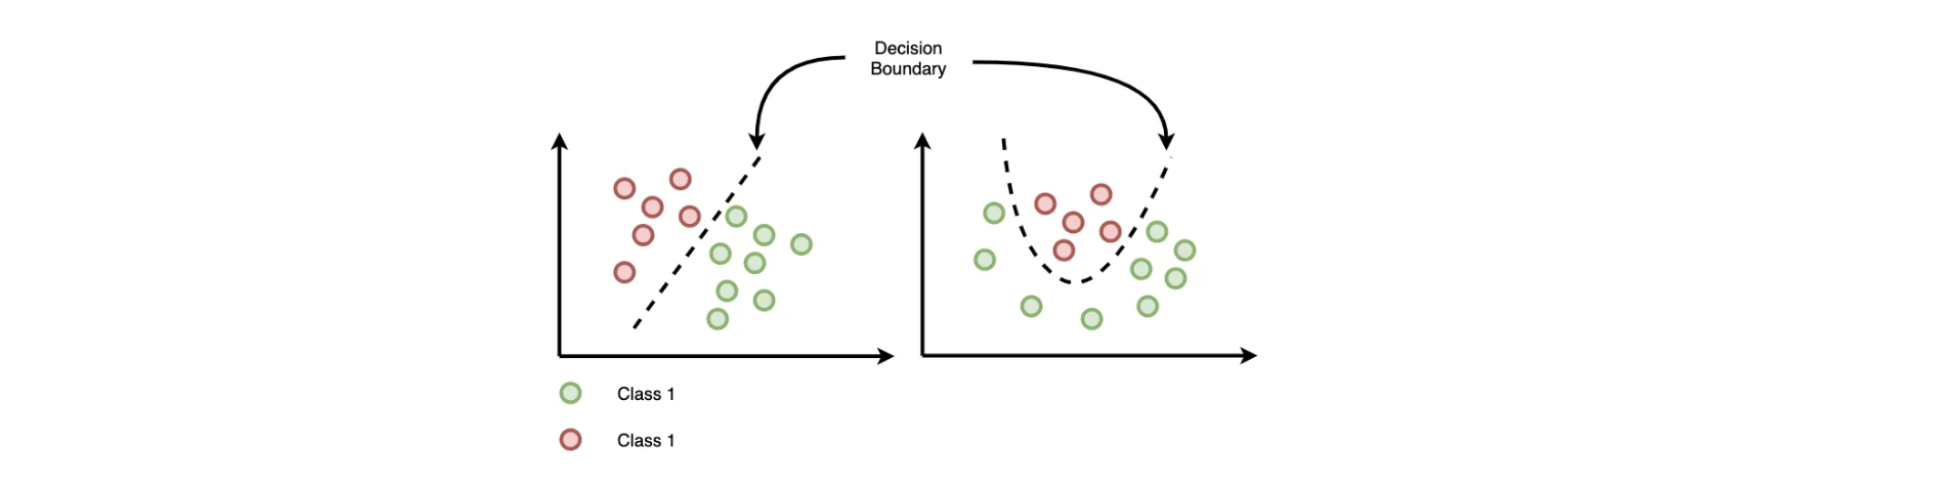

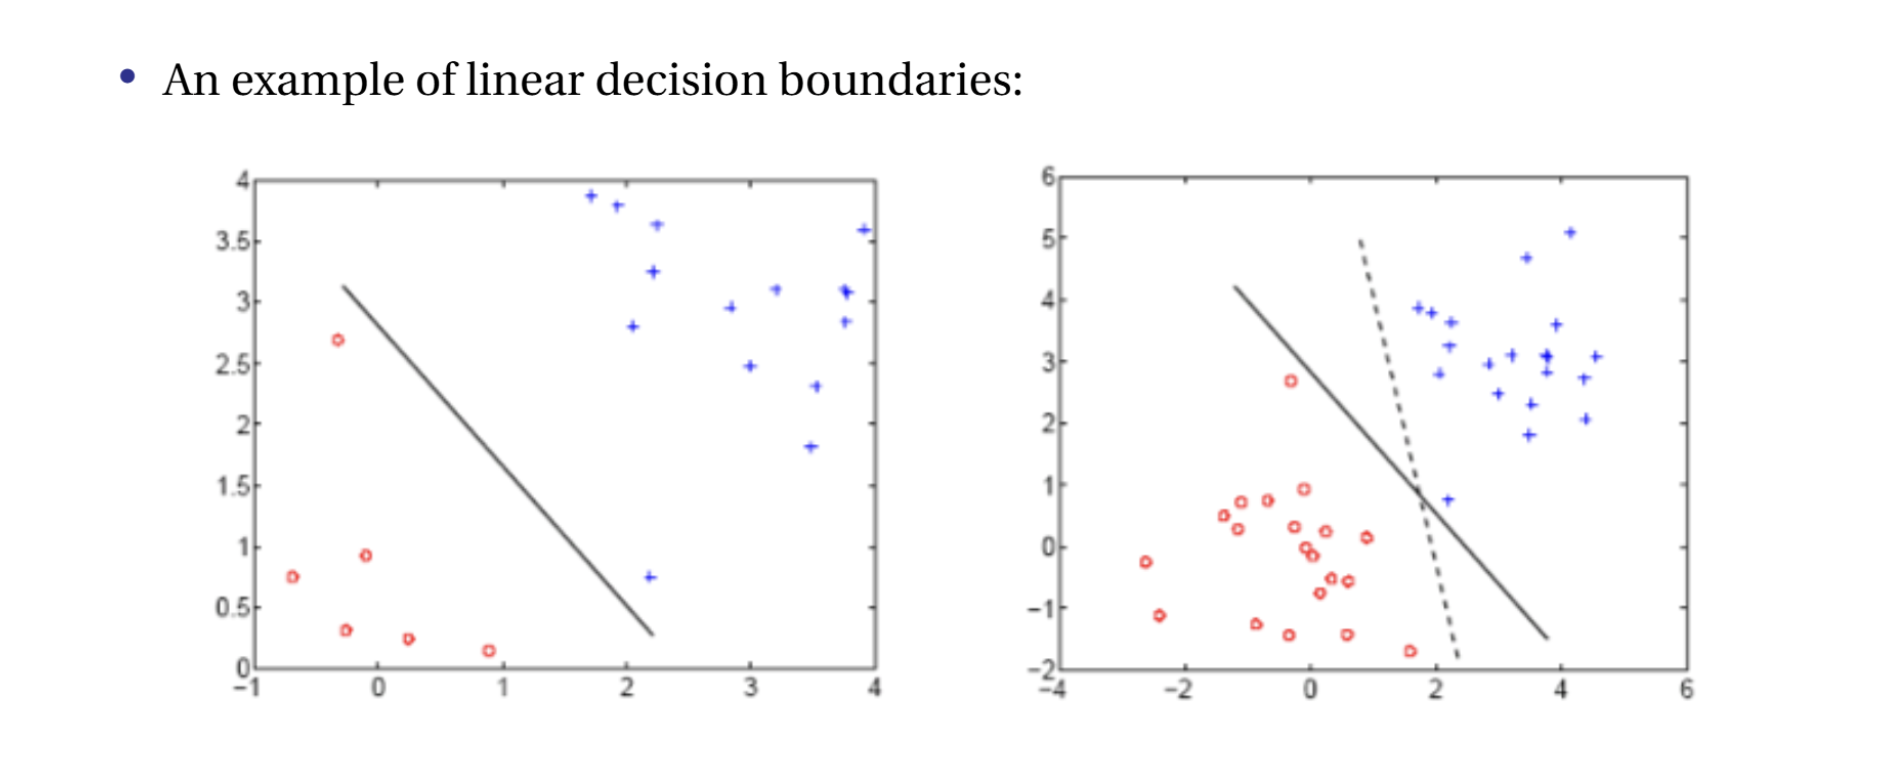


To find the  decision surface we equal the function to a **constant**(where probability of both classes are the same):

$$\sigma(w^Tx) = \frac{1}{1 + e^{-(w^Tx)}} = 0.5$$

Decision surfaces are **linear functions** of x:

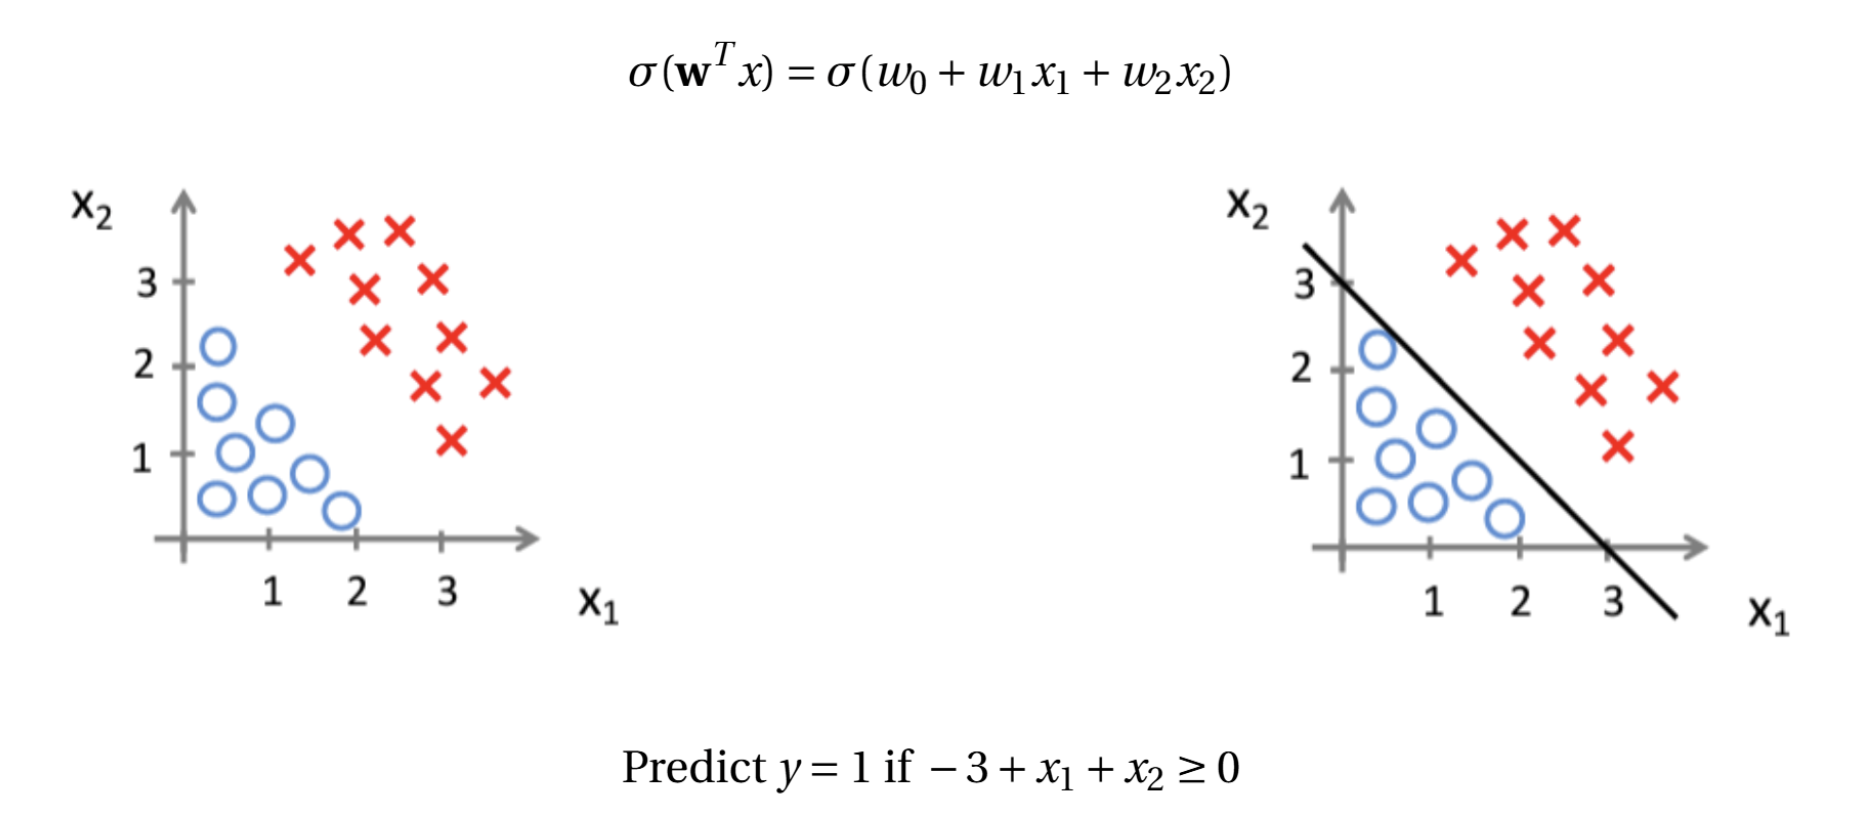

Like in the previous sections there are times that the distribution of our data is not linear or something near that and it has some  other distribution like the figure below, for this moments we try to add some non linear and polynomial charasteristics to the decision boundry by creating some new features using previous features and increase their degree:

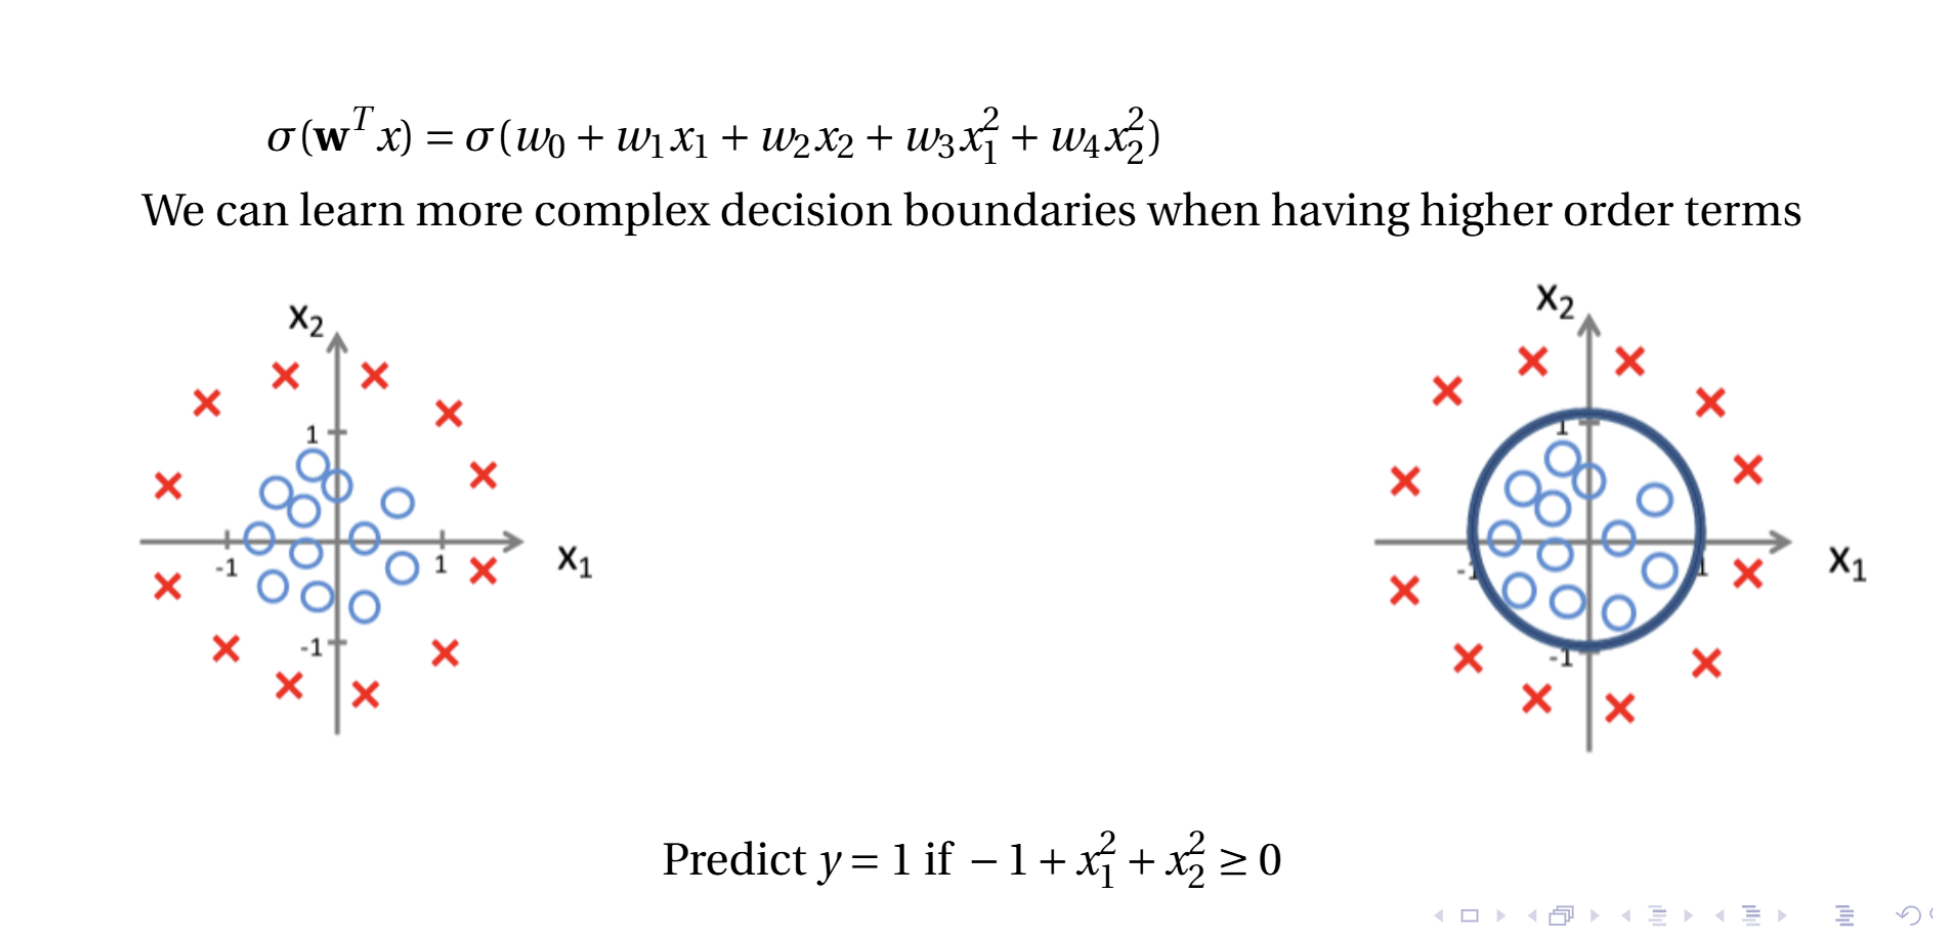


## ML(maximum Likelihood) Estimation:


Let's start with a definition of **statistics** and **probability**:

+ **Probability**: 

    It has a whole to part characteristics. Let's explain this with a an example:
    Think we know and have the distribution model of a random variable which is a normal distribution with mean of 3 and varaince of 5. Now the question of the probability problem is to find the result of $P(1 \leq x \leq 6)$, we should find the *probability* of the x being in between 1 and 6 in the  given and known distribution model. This is called **probability**

+ **Statistics**:

    Contrary to probability our approach here part to whole and we tend to obtain a model or something from data samples.
    For example we have picked randomly 15 people from a population as sample and have measured their heights and now we wanna obtain the parameters of the total distribution from these samples.


+ **Estimation**:

    When we wanna get/estimate the parameters of our total distribution from a data sample.


> One of the most used approaches for estimation is: Maximum Likelihood Estimation.

Let's explain ML estimation with an example first:

For example that we wanna throw a coin and wanna estimate the probability of the coin becomes 1(head) so that in 16 times that we're gonna throw the coin, 12 times of it result in head. The equation of this happening is like below:

$$\binom{16}{12}p_{h}^{12}(1-p_{h})^4$$

And now we wanna estimate a $p_h$ using ml estimation so that that equation above becomes maximum

$$\hat{p_h} = \argmax_{p} \binom{16}{12}p_{h}^{12}(1-p_{h})^4 = \argmax_{p} p_{h}^{12}(1-p_{h})^4$$

Now we can take logarithm from the equation above(why? cause when something is becoming maximum it's logarithm will become maximm to cause the logarithm function is an ascending function):

$$\hat{p_h} = \argmax_{p} \log{p_{h}^{12}(1-p_{h})^4} = \argmax_{p} 12\log{p_{h}} + 4\log{(1-p_{h})}$$

For calculating the $p_h$ that would result in the maximum of the equation above we should calculate the derivation of the equation above  based on $p_h$ and equal zero:


$$\frac{\partial 12\log{p_{h}} + 4\log{(1-p_{h})}}{\partial p_h} = \frac{12}{p} - \frac{4}{(1-p)} = 0$$

So solving the euqation above we get to:

$$\hat{p_h} = \frac{12}{16}$$

The $\hat{p_h}$ is the estimation of the $p_h$ which is set for our question.

> This is the maximum likelihood and we made a example for it first to have better intuition of what we're trying to do with maximum likelihood in general. It can be done for the bernoli distribution that we had an example of or calculating $\mu$ in a normal distribution or $\sigma^2$ in a normal distribution and there are lots of **parameters** that we're able to estimate with maximum likelihood.


Now let's bring this maximum likelihood to logistic regression:

We had posterior of a sample as:
$$P(y^{(i)} | x^{(i)}, w)$$

Logistic regression should maximize production of all these samples posteriors:

$$\hat{w} = \argmax_{w} \log{\prod_{i = 1}^{n} P(y^{(i)} | x^{(i)}, w)}$$

> We're considering that each $(x^{(i)}, y^{(i)})$ are independent from each other and when we suppose that we can multiply their probabilities => We're collecting random samples from all the population and not the related samples.

> The equation above gives us the **objective function** for training logistic regression.

logarithm of products become sum of the logarithm of those functions:
$$\hat{w} = \argmax_{w} \sum_{i = 1}^{n} \log{P(y^{(i)} | x^{(i)}, w)}$$

And we know that in binary classification $y$ is either 1 or 0, so we can have posterior term simplified as follows:
$$P(y^{(i)} | x^{(i)}, w) = \sigma(w^Tx^{(i)})^{y^{(i)}} (1 - \sigma(w^Tx^{(i)}))^{1-y^{(i)}}$$


Now calculating the logarithm of that probability function which expanded in the equation above:

$$\log{P(y^{(i)} | x^{(i)}, w)} = y^{(i)} \log{(\sigma(w^Tx^{(i)}))} + {(1-y^{(i)})} \log{(1 - \sigma(w^Tx^{(i)}))}$$

Now we're going to have:

$$\hat{w} = \argmax_{w} \sum_{i = 1}^{n} y^{(i)} \log{(\sigma(w^Tx^{(i)}))} + {(1-y^{(i)})} \log{(1 - \sigma(w^Tx^{(i)}))}$$

Now for calculating the optimal w  that would make our equation maximum we should get the derivation of the equation to the w:

$$\frac{\partial \sum_{i = 1}^{n} y^{(i)} \log{(\sigma(w^Tx^{(i)}))}}{\partial w} = \sum_{i = 1}^{n} y^{(i)} x^{(i)} (1 - \sigma(w^Tx^{(i)}))$$

$$\frac{\partial \sum_{i = 1}^{n} ({1-y^{(i)}}) \log{(1 - \sigma(w^Tx^{(i)}))}}{\partial w} = \sum_{i = 1}^{n} (y^{(i)} - 1) x^{(i)} \sigma(w^Tx^{(i)})$$

We blend the two equations above:

$$\sum_{i=1}^{n} x^{(i)} \underbrace{(\underbrace{y^{(i)}}_{\text{real label}} - \underbrace{\sigma(w^{T}x^{(i)})}_{\text{predicted}})}_{\text{Error}}$$

> The above equation is the **gradient** of the **log-lokelihood function** (or equivalently, the **negative gradient of the cross-entropy loss**). It tells us how to update the weights $w$ to improve our model.

+ **What the above equation is used for?**

    To update the weights using gradient descent or in SGD form(sample by sample)

**What it means conceptually?**

+ If our model **underestimates** $y^{(i)}$, i.e., $\hat{y}^{(i)} < y^{(i)}$ then $y^{(i)} - \hat{y}^{(i)} > 0$, The gradient is positive so it move weights to increase prediction.

+ If our model **overestimates**, i.e., $\hat{y}^{(i)} > y^{(i)}$ then $y^{(i)} - \hat{y}^{(i)} < 0$, The gradient is **negative** and we would move weights to decrease prediction 

> So that gradient equation is telling us how wrong the model is(error), and in what direction we should adjust the weights(based on the features $x^{(i)}$) to fix it. 

Concluding from the above we just have to multiply $x^{(i)}$ to the error and we will get the gradient.

### Cost Function:

As the previous trends we need a cost function to minimize and make our model optimal for our samples and dataset.

We should find:
$$\hat{w} = \argmin_{w} J(w)$$

As seen above **Maximum Likelihood** finds parameters that best describe a classification problem so cost function should be negative of log likelihood term:


$$Likelihood = \mathcal{L(w)} = \prod_{i = 1}^{n} P(y^{(i)} | x^{(i)}, w)$$
$$J(w) = - \log{\mathcal{L(w)}} = -\sum^{i = 1}_{n} \log{(P(y^{(i)} | x^{(i)}, w))}$$

**Why do we make the loss function equal to the negative log-likelihood?**:

+ Because machine learning frameworks are built to minimize things, not maximize:
+ We want to maximize log-likelihood (good model = high probability of correct labels)
+ But all the standard optimization algorithms (like gradient descent) are designed to minimze a cost function

So we do this:

$$\min_{w} (-log Likelihood)$$

which is mathematically equivalent to:

$$\max_{w} (log Likelihood)$$

We cannot have a closed form equation like what we had in linear regression and find a single formula to optimize the cost function, so in here we again use **Gradient Descent** and update the weights iteratively and we see that $J(w)$ would convex.

Visualize of each binary cross entropy loss term:

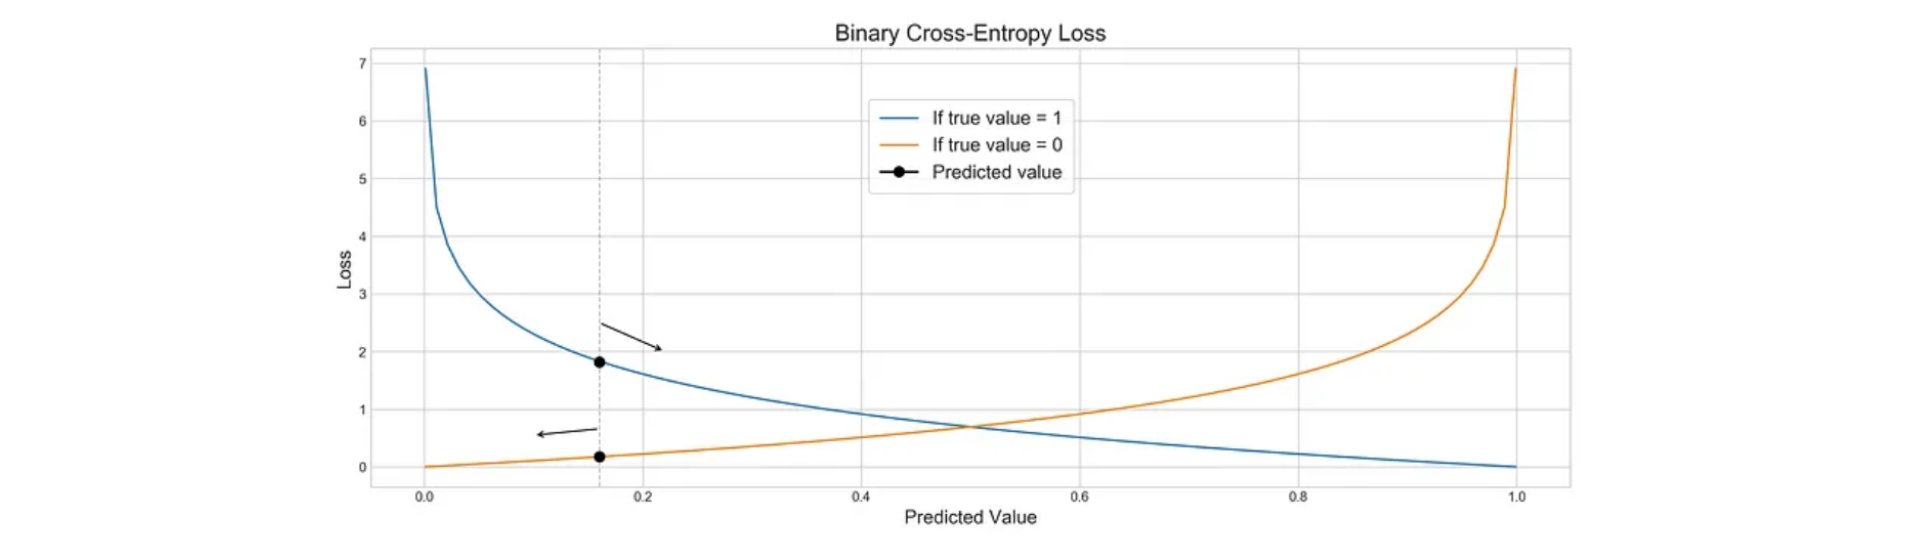

> As you can see in the above figure if the model predicted value is $\hat{y} =0.16$ and true label is $y = 1$ then the error is high but if the true label is $y = 0$ the error would be low


### Gradient Descent:

Update rule for the gradient descent is:
$$w^{t+1} = w^t - \eta \nabla_{w}J(w^T)$$